In [ ]:
# Все нужные импорты

import pdfplumber
import os
import pandas as pd
import re
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pickle as pkl
from pathlib import Path
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.model_selection import KFold
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

# Предобработка данных

### Импорт pdf

In [2]:
# Список путей к папкам с PDF файлами
folder_paths = [
    r"C:\Users\Петр\OneDrive\Рабочий стол\Для Хакатона\ЭНА",
    r"C:\Users\Петр\OneDrive\Рабочий стол\Для Хакатона\Тюмень",
    r"C:\Users\Петр\OneDrive\Рабочий стол\Для Хакатона\СН",
    r"C:\Users\Петр\OneDrive\Рабочий стол\Для Хакатона\ОМ",
    r"C:\Users\Петр\OneDrive\Рабочий стол\Для Хакатона\КН"
]

# Список для хранения полных путей к файлам
pdf_full_paths = []
pdf_files = []

# Проходим по каждой папке и собираем имена и пути PDF файлов
for folder in folder_paths:
    try:
        for f in os.listdir(folder):
            if f.endswith('.pdf'):
                pdf_full_paths.append(os.path.join(folder, f))
                pdf_files.append(f)
    except FileNotFoundError:
        print(f"Внимание: Папка не найдена, пропускаю: {folder}")

# Словарь для хранения извлеченных данных
pdf_data = {}

# Используем полные пути для открытия файлов, а имена - для ключей
for file_path in pdf_full_paths:
    file_name = os.path.basename(file_path)
    text_content = ""
    tables = []

    try:
        with pdfplumber.open(file_path) as pdf:
            # Извлекаем текст с каждой страницы
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text_content += page_text + "\n"
            
            # Извлекаем таблицы
            for page in pdf.pages:
                extracted_tables = page.extract_tables()
                if extracted_tables:
                    for table in extracted_tables:
                        if table and len(table) > 1: # Проверяем, что таблица не пустая и есть заголовок
                            df = pd.DataFrame(table[1:], columns=table[0])
                            tables.append(df)

        # Сохраняем извлеченные данные
        pdf_data[file_name] = {
            'text': text_content,
            'tables': tables
        }
    except Exception as e:
        print(f"Не удалось обработать файл {file_name}: {e}")
len(pdf_files)

94

In [3]:
for i, file in enumerate(pdf_files):
    print(i, file)

0 Д0 Высокое 25.02.25_ЭНАЛБ.pdf
1 Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ.pdf
2 Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf
3 Д1 ДОБРИНО 25.02.25_ЭНАЛБ.pdf
4 ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ.pdf
5 ЖК Бобров Д1 (КК-11) 21.05.25_ЭНАВ.pdf
6 ЖК Бобров Д1 (КК-11) 25.02.24 (1)_ЭНАВ.pdf
7 ЖК Бобров-2 Д1 (КК-10) 25.02.25(2)_ЭНАВ.pdf
8 ЖК Бобров-2 Д1 (КК-10) Без патоки 24.04.24(2)_ЭНАВ.pdf
9 ЖК Бобров-2 Д1 (КК-11) 21.05.25 (2)_ЭНАВ.pdf
10 ЖК Бобров-2 Д1 (КК-11) 21.05.25(1)_ЭНАВ.pdf
11 ЖК Бобров-2 Д1 (КК-11) 25.02.25(1)_ЭНАВ.pdf
12 ЖК Бобров-2 Д1 (КК-11) Без патоки 24.04.24 (1)_ЭНАВ.pdf
13 ЖК В. Икорец Д1 (КК-11) 21.05.25_ЭНАВ.pdf
14 ЖК Петропавловка Д0 (КК-11) 12.03.25_ЭНАВ.pdf
15 ЖК Петропавловка Д1 (КК-10) 12.03.25_ЭНАВ.pdf
16 ЖК Петропавловка Д1 (КК-11) 12.03.25_ЭНАВ.pdf
17 ЖК Петропавловка Д1 (КК-11) 26.06.25_ЭНАВ.pdf
18 ЖК Петропавловка Д3 (КК-10) 12.03.25_ЭНАВ.pdf
19 МТФ Петропавловка Д3 (КК-10) 26.06.25_ЭНАВ.pdf
20 Отчет_Д1 Бодеевка 26.06.25_ЭНАЛБ.pdf
21 Отчет_Д1 Высокое 21.05.25_ЭНАЛБ.pdf
2

### Подготовка данных о компонентах рациона

In [4]:
# Пробный парсинг таблицы
df = pdf_data[pdf_files[14]]['tables'][0]
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)[:-1]
df

,Ингредиенты,СВ %,ГП кг,СВ кг,% ГП,% СВ
0,Солома ЭНА Восточное -,"82,990","1,566","1,300","4,54","7,22"
1,Силос 3636.07.05.02.1.24 -,"32,500","15,385","5,000","44,56","27,78"
2,Люцерна 3637.04.01.01.3.24 -,"35,800","4,246","1,520","12,30","8,44"
3,Тритикале 3636.01.12.01.1.24 -,"29,000","2,828","0,820","8,19","4,56"
4,"Патока свекловичная, сахар","79,500","0,881","0,700","2,55","3,89"
5,"Шрот соевый. 49%, ЭНАПКХ","89,750","2,540","2,280","7,36","12,67"
6,"Шрот рапсовый. 38%, ЭНАПКХ","91,800","1,057","0,970","3,06","5,39"
7,Соевая оболочка ЭНАПКХ,"90,200","0,776","0,700","2,25","3,89"
8,"Кукуруза. 70%,сухая средн.\nпомол, ЭНАПКХ","87,540","2,810","2,460","8,14","13,67"
9,Комбикорм 11.3.3 (без пшен.)\n_Сентябрь 09.09.24,"92,246","2,439","2,250","7,06","12,50"


In [5]:
wides = []

for file in pdf_files:
    try:
        df = pdf_data[file]['tables'][0]
        df.columns = df.iloc[0]
        df = df[1:].reset_index(drop=True)[:-1]
    
        # --- очистка названий
        names = (df['Ингредиенты']
                 .astype(str)
                 .str.split('/', n=1).str[0]
                 # .str.replace(r'\s*\d.*$', '', regex=True)
                 .str.strip(' .,\u00A0')
        )
        df = df.copy()
        df['Ингредиенты'] = names
    
        # --- числа
        df['% СВ'] = (df['% СВ'].astype(str)
                      .str.replace(' ', '', regex=False)
                      .str.replace('\u00A0', '', regex=False)
                      .str.replace(',', '.', regex=False)
                      .astype(float))
        df['СВ кг'] = (df['СВ кг'].astype(str)
                      .str.replace(' ', '', regex=False)
                      .str.replace('\u00A0', '', regex=False)
                      .str.replace(',', '.', regex=False)
                      .astype(float))
        day_total = df['СВ кг'].sum()
        
        # --- wide
        s = df.groupby('Ингредиенты', as_index=True)['СВ кг'].sum()
        wide = s.to_frame().T.reset_index(drop=True)
        wide.insert(0, '__source', file)
    
        wides.append(wide)
    except Exception as e:
        print(file, e)
        continue


# конкат со всеми разными столбцами
result = pd.concat(wides, ignore_index=True, sort=False)
num_cols = result.columns.difference(['__source'])
result[num_cols] = result[num_cols].fillna(0)

# порядок колонок — сначала источник, потом по алфавиту
result = result[['__source'] + sorted([c for c in result.columns if c != '__source'])]
result

Рацион Д1 ЖК Озерки 24.04.2024 ЭНАЮ.pdf list index out of range
Рацион Д1ЖК Озерки 26.06.2025_ЭНАЮ.pdf could not convert string to float: 'Стоимость$525'


Ингредиенты,__source,1603.01.05.06.1.24,1603.01.05.07.1.24,1603.02.05.02.1.24,1603.02.15.04.1.24,1603.03.01.01.1.24,1603.05.01.01.1.24,1630.01.12.01.1.24,1630.02.01.01.1.24,1630.03.01.01.1.24,...,с-с 27.02.25\4030.01.05.02.1.24 Прудки,с-с 4029.03.05.02.1.23,с-с 6204.01.05.02.1.24,силос 9202.04.05.02.1.24,силос9202.01.05.02.1.24,силос_9202.04.05.02.1.24,солома,солома ячменная,солома6601.24.15.04.1.24.15.07,суданка6601.30.06.01.2.24.15.0
0,Д0 Высокое 25.02.25_ЭНАЛБ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
88,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
89,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ.pdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
print(result.columns.tolist())

['__source', '1603.01.05.06.1.24', '1603.01.05.07.1.24', '1603.02.05.02.1.24', '1603.02.15.04.1.24', '1603.03.01.01.1.24', '1603.05.01.01.1.24', '1630.01.12.01.1.24', '1630.02.01.01.1.24', '1630.03.01.01.1.24', '1630.07.02.01.1.24', '1630.10.05.02.1.23', '1630.14.05.02.1.23', '1630.17.05.07.1.24', '2221.02.05.02.1.23 Силос', '2531.01.01.01.2.24', '2531.04.05.02.1.24', '2531.05.05.02.1.23', '2531.05.05.02.1.24', '3635.01.01.01.1.23', '3635.01.01.01.1.24', '3635.05.05.02.1.24', '3638.02.01.01.2.24', '3638.02.01.01.3.24 CP', '3638.04.05.02.1.23', '5001.01.01.01.1.23', '5001.02.16.01.1.23', '5100.01.05.02.1.24', '5100.01.05.07.1.24', '5100.01.10.01.1.24', '5210.03.03.01.1.24', '5210.07.05.02.1.24', '5701.01.01.01.1.24', '5701.01.01.01.1.25', '5701.01.05.07.1.24', '5701.01.05.1.23', '5701.02.05.02.1.24', '5701.03.05.02.1.24', '5701.04.01.01.3.24', '5701.04.05.07.1.24', '6101.08.06.02.1.24', '6110.01.01.01.1.24 люцерна', '6110.06.18.01.1.24', '6110.09.05.02.1.24', '6110.10.18.01.1.24', '6601

In [8]:
# Полный список колонок
ingredient_columns = result.columns.tolist()

# Классификация по группам, чтобы снизить размерность
feed_map = {
    'Силос': [
        'Силос', 'силос', 'силос_', 'C-C', 'c-c', 'С-С', 'с-с', 'С-С 2242.05.05.02.1.23\\',
        '1603.02.05.02.1.24', '1630.10.05.02.1.23', '1630.14.05.02.1.23', '2221.02.05.02.1.23 Силос',
        '2531.04.05.02.1.24', '2531.05.05.02.1.23', '2531.05.05.02.1.24', '3635.05.05.02.1.24',
        '3638.04.05.02.1.23', '5100.01.05.02.1.24', '5210.07.05.02.1.24', '5701.02.05.02.1.24',
        '5701.03.05.02.1.24', '6101.08.06.02.1.24', '6110.09.05.02.1.24', '6601.40.05.02.1.24',
        'C-C 2261.03.05.02.1.23', 'c-c 4029.04.05.02.1.23', 'С-С 2241.04.05.02.1.24 СР',
        'С-С 2242.01.05.02.1.24', 'С-С 2242.03.05.02.1.24', 'С-С 2242.03.05.02.1.24 \\ 12.03.25',
        'С-С 2242.05.05.02.1.23\\\n11.04.24', 'С-С 2261.04.05.02.1.23 \\ 12.03.25',
        'С-С 2262.04.05.02.1.24', 'С-С 2392.05.05.02.1.24', 'С-С 2392.07.05.02.1.24 \\ 12.03.25',
        'С-с 4029.01.05.02.1.24 Уланово22.04.25', 'С-с 6201.10.05.02.1.23', 'С-с 6203.05.05.02.1.24',
        'Силос 22.02.02.05.02.1.24', 'Силос 2201.03.05.02.1.24', 'Силос 2211.03.05.02.1.24',
        'Силос 2221.03.05.02.1.24', 'Силос 2232.03.05.02.1.24', 'Силос 2291.03.05.02.1.24',
        'Силос 2291.04.05.02.1.24', 'Силос 2371.04.05.02.1.24 -', 'Силос 2371.05.05.02.1.23 -',
        'Силос 2501.05.05.02.1.24 -', 'Силос 3636.07.05.02.1.24 -', 'Силос 3637.05.05.02.1.23 -',
        'Силос 3637.06.05.02.1.23 -', 'Силос 3637.07.05.02.1.24 -', 'с-с 17.04\\5901.01.05.02.1.24 Аристово',
        'с-с 21.03.25\\5204.01.05.02.1.24 Болдасовка', 'с-с 23.06.2025\\4030.01.05.02.1.24 Прудки',
        'с-с 23.06.2025\\5901.01.05.02.1.24.Аристово', 'с-с 25.03.25\\5901.01.05.02.1.24 Аристово',
        'с-с 27.02.25\\4030.01.05.02.1.24 Прудки', 'с-с 4029.03.05.02.1.23', 'с-с 6204.01.05.02.1.24',
        'силос 9202.04.05.02.1.24', 'силос9202.01.05.02.1.24', 'силос_9202.04.05.02.1.24',
        'кукуруза6601.40.05.02.1.24.15.0'
    ],
    'Сенаж': [
        'Сенаж', 'С-Ж', 'с-ж', 'Люцерна', 'люцерна', 'люц_', 'суданка', 'рожь_',
        '1603.03.01.01.1.24', '1603.05.01.01.1.24', '1630.01.12.01.1.24', '1630.02.01.01.1.24',
        '1630.03.01.01.1.24', '1630.07.02.01.1.24', '2531.01.01.01.2.24', '3635.01.01.01.1.23',
        '3635.01.01.01.1.24', '3638.02.01.01.2.24', '3638.02.01.01.3.24 CP', '5001.01.01.01.1.23',
        '5001.02.16.01.1.23', '5100.01.10.01.1.24', '5210.03.03.01.1.24', '5701.01.01.01.1.24',
        '5701.01.01.01.1.25', '5701.04.01.01.3.24', '6110.01.01.01.1.24 люцерна', '6110.06.18.01.1.24',
        '6110.10.18.01.1.24', '6601.07.06.01.1.24', '6601.25.01.01.2.24', 'c-ж 6204.01.12.01.1.24',
        'Люцерна 2501.03.01.01.2.24 -', 'Люцерна 2501.04.08.01.1.24 -', 'Люцерна 3637.01.01.01.1.24 -',
        'Люцерна 3637.03.01.01.2.23 -', 'Люцерна 3637.03.01.01.2.24 -', 'Люцерна 3637.04.01.01.3.24 -',
        'Люцерна2371.01.01.01.2.24 -', 'С-Ж 2241.02.04.01.1.24', 'С-Ж 2241.03.04.01.1.23',
        'С-Ж 2242.01.04.01.1.23\\', 'С-Ж 2242.02.01.01.1.24', 'С-Ж 2242.02.08.01.1.24',
        'С-Ж 2242.02.08.01.1.24 \\ 12.03.25', 'С-Ж 2242.03.08.01.2.23\\', 'С-Ж 2262.01.01.01.1.24',
        'С-Ж 2262.01.01.01.1.24 \\ 12.03.25', 'С-Ж 2262.03.01.01.2.24', 'С-Ж 2262.05.10.01.1.24',
        'С-Ж 2262.05.10.01.1.24 \\ 12.03.25', 'С-Ж 2262.08.08.01.2.24', 'С-Ж 2392.01.01.01.1.24',
        'С-Ж 2392.01.01.01.1.24 \\ 12.03.25', 'С-Ж 2392.04.10.01.2.24', 'С-Ж 2392.04.10.01.2.24 \\ 12.03.25',
        'С-ж 4019.02.09.01.2.24 Косово- клевер', 'С-ж 4019.02.09.01.2.24 Косово1',
        'С-ж 4029.01.01.01.1.25 Уланово', 'С-ж 4032.01.01.01.1.25 Гусево', 'С-ж 5701.01.01.01.1.24 Бушовка',
        'С-ж 6201.07.01.01.1.24', 'С-ж 6202.02.01.01.1.24 03.02.25', 'Сенаж 22.02.01.01.01.1.24',
        'Сенаж 2201.02.01.01.2.24', 'Сенаж 2211.02.01.01.2.24', 'Сенаж 2221.02.08.01.1.24',
        'Сенаж 2232.02.08.01.2.24', 'Сенаж 2291.01.01.01.2.24', 'Сенаж 2291.02.01.01.3.24',
        'с-ж 17.04\\5902.01.01.01.1.24 Сугоново', 'с-ж 21.03.25', 'с-ж 21.03.25\\4030.06.01.01.1.24 Детчино',
        'с-ж 21.03.25\\5110.01.08.01.1.24 Дурово', 'с-ж 21.03.25\\5313.02.01.01.2.24',
        'с-ж 22.08.24\\4030.11.01.01.2.24 Санталовка', 'с-ж 6204.01.12.01.1.24', 'с-ж 6204.06.01.01.2.24',
        'с-ж 8.05.25\\5110.01.08.01.1.24 Дурово', 'с-ж 8.05.25\\5313.03.01.01.3.24 Поливаново',
        'с-ж4029.09.01.01.3.23', 'люц_9202.04.01.01.1.24', 'люцерна6601.29.08.01.1.24.15',
        'люцерна_9202.04.01.01.1.24\\06', 'рожь_9202.02.13.01.1.24',
        'суданка6601.30.06.01.2.24.15.0'
    ],
    'Сено': [
        'Сено из люцерны', 'Сено луговое', 'Сено луговое ЛБ', 'Сено люцерна ЛБ',
        'Сено луговое 2024', 'Сено люцерна ЛБ 2025'
    ],
    'Солома': [
        'Солома', 'солома', 'Солома ЭНА Восточное -', 'солома ячменная', 'Пшеничная солома',
        'Солома пшеничная', 'Солома пшеничная ЛБ', 'Солома-пшеничная ОМ Север', 'Дробленая солома КН Восток',
        '1603.02.15.04.1.24', 'Солома пшеничная 2024', 'солома6601.24.15.04.1.24.15.07'
    ],
    'Кукуруза_сухая': [
        'Кукуруза', 'кукуруза', 
        'Кукуруза. 70%,сухая средн.\nпомол, ЭНАПКХ',
        'Кукуруза. 70%,сухая, мелк.\nпомол, ЭНАПКХ',
        'Кукуруза. 65%,сухая средн', 'Кукуруза. 65%,сухая средн. помол',
        'Кукуруза. 70%,сухая средн', 'Кукуруза. 70%,сухая средн. помол, ЭНАПКХ',
        'Кукуруза. 70%,сухая, мелк', 'Кукуруза. 70%,сухая, мелк. помол',
        'Кукуруза. 70%,сухая, мелк. помол, ЭНАПКХ'
    ],
    'Кукуруза_влажная': [
        'Кукуруза влажная, кр', 'Плющенная кукуруза ток', 'плющенная кукуруза',
        'Плющ зерно 6203.06.05.06.1.24', 'кукуруза_плющ_', 'плющенное',
        '1603.01.05.06.1.24', '6601.48.05.06.1.24', 'Кукуруза влажная, кр. 68%',
        'Плющ зерно 6203.06.05.06.1.24\n03.02.25', 'Плющенная кукуруза ток1',
        'кукуруза_плющ_9202.01.05.06', 'плющенное6601.48.05.06.1.24'
    ],
    'Зерновые_прочие': [
        'Тритикале', 'Ячмень', 'Ячмень. сухой',
        'Ячмень. сухой 53%, средний\nпомол, ЭНАПКХ',
        'Ячмень.61%, сухой, средний\nпомол, ЭНАПКХ',
        'Пшеница', 'пшеница_консерв_СНБ',
        'Пшеница. 55%, сухая.средн', 'Пшеница. 55%, сухая.средн. помол',
        'Пшеница. 55%, сухая.средн. помол, ЭНАПКХ',
        'Тритикале 2501.02.12.01.1.24 -', 'Тритикале 3636.01.12.01.1.24 -',
        'Тритикале 3637.01.12.01.1.23 -', 'Тритикале 3637.02.12.01.1.24 -',
        'Ячмень. сухой 53%, средний', 'Ячмень. сухой 53%, средний помол',
        'Ячмень. сухой 53%, средний помол, ЭНАПКХ', 'Ячмень.60%, сухой, средний',
        'Ячмень.60%, сухой, средний помол', 'Ячмень.61%, сухой, средний'
    ],
    'Корнаж_ЗСК': [
        'Корнаж', 'корнаж', 'карнаж', 'корнаж_', 'ЗСК', 'ЗСК 6202.05.05.07.1.23', 'к-ж', 'к-ж Детч',
        '1603.01.05.07.1.24', '1630.17.05.07.1.24', '5100.01.05.07.1.24', '5701.01.05.07.1.24',
        '5701.01.05.1.23', '5701.04.05.07.1.24', '6601.49.05.07.1.24',
        'ЗСК 6201.05.05.07.1.22', 'ЗСК 6202.05.05.07.1.23\n03.02.2025 (Res#1) MA1',
        'Корнаж 2371.06.05.07.1.23 -', 'Корнаж 2501.08.05.07.1.23 -', 'Корнаж 2501.09.05.07.1.23 -',
        'к-ж 17.04\\5204.01.05.07.1.24 Болдасовка', 'к-ж 23.12.24\\5204.01.05.07.1.24 Болдасовка',
        'к-ж 6204.01.05.07.1.24', 'к-ж 6204.02.05.07.1.23', 'к-ж 8.05.25\\5204.01.05.07.1.24 Болдасовка',
        'к-ж Детч 4030.02.05.07.1.24_04.04.2025', 'к-ж4030.05.05.07.1.24 Детчино 25.06.25',
        'к-ж5701.05.07.1.23 Бушовка', 'карнаж6601.49.05.07.1.24.15.07', 'корнаж_9202.03.05.07.1.23'
    ],
    'Шрот_соевый': [
        'Шрот соевый', 'Шрот соевый. 47%, ЭНАПКХ', 'Шрот соевый. 49%, ЭНАПКХ',
        'Шрот соевый. 51%, ЭНАПКХ', 'Шрот соевый. 52%, ЭНАПКХ'
    ],
    'Шрот_рапсовый': [
        'Шрот рапсовый', 'Шрот Рапсовый', 'Шрот рапсовый. 38%', 'Шрот рапсовый. 38%, ЭНАПКХ',
        'Шрот рапсовый. 41%', 'Шрот рапсовый. 41%, ЭНАПКХ', 'Шрот рапсовый. 42%',
        'Шрот рапсовый. 44%, ЭНАПКХ'
    ],
    'Шрот_подсолнечный': [
        'Шрот подсолнечный', 'Шрот подсолнечный. 38%'
    ],
    'Жмых_рапсовый': [
        'Жмых рапсовый', 'Жмых рапсовый СП', 'Жмых рапсовый СП 39, ЭНАПКХ',
        'Жмых рапсовый. 35%', 'Жмых рапсовый. 36%', 'Жмых рапсовый. 36%, ЭНАПКХ',
        'Жмых рапсовый. 39%', 'Жмых рапсовый. 39%, ЭНАПКХ'
    ],
    'Жмых_льняной': [
        'Жмых льняной', 'Жмых льняной. 36%, ЭНАПКХ'
    ],
    'Жом_свекловичный': [
        'Жом свекловичный сухой', 'Жом свекловичный сухой. гр',
        'Жом свекловичный сухой. гр, ЭНАПКХ v',
        'Жом свекловичный сухой. гранула, ЭНАПКХ',
        'Жом свекловичный сухой. гр, ЭНАПКХ v2'
    ],
    'Патока_свекловичная': [
        'Патока свекловичная', 'Патока свекловичная,\nсах',
        'Патока свекловичная, сах',
        'Патока свекловичная, сах.49%,\nЭНАПКХ v',
        'Патока свекловичная, сах.49%, ЭНАПКХ\nv',
        'Патока свекловичная, сахар', 'Меласса свекловичная',
        'Патока свекловичная,\nсах.49%, ЭНАПКХ v2', 'Патока свекловичная, сах.49%',
        'Патока свекловичная, сах.49%,\nЭНАПКХ v2', 'Патока свекловичная, сах.49%, ЭНАПКХ',
        'Патока свекловичная, сах.49%, ЭНАПКХ\nv2',
        'Патока свекловичная, сахар\n55%, ЭНАПКХ', 'Патока свекловичная, сахар 55%',
        'Патока свекловичная, сахар 55%, ЭНАПКХ'
    ],
    'Побочные_прочие': [
        'Соевая оболочка ЭНАПКХ', 'Дробина сухая', 'Дрожжи кормовые. СП', 'Пивные дрожжи сухие',
        'Дробина сухая. 27%, пивная', 'Дрожжи кормовые. СП 37%'
    ],
    'Комбикорма': [
        'Комбикорм', 'Комбикорм -', 'Комбикорм 10.3.3 (без пшен.)\n_Сентябрь',
        'Комбикорм 11.3.3 (без пшен.)\n_Сентябрь', 'Комбикорм №', 'КК', 'Комбиком №', 'ККД',
        'Кормосмесь', 'ккз аристово v', 'КК 10 Аристово 11.03.25', 'КК 10 От 03.01.24',
        'КК 10 От 17.09.24 ячмень', 'КК №10', 'КК10', 'ККД10 Аристово', 'Комбиком №10',
        'Комбиком №13', 'Комбикорм -\n11', 'Комбикорм 10.3.3 (без пшен.)',
        'Комбикорм 10.3.3 (без пшен.)\n_Сентябрь 09.09.24', 'Комбикорм 10.3.3_Январь',
        'Комбикорм 11.3.3 (без пшен.)', 'Комбикорм 11.3.3 (без пшен.)\n_Сентябрь 09.09.24',
        'Комбикорм 11.3.3 (без пшен.)\n_Сентябрь 12.03.25', 'Комбикорм 11.3.3_Январь',
        'Комбикорм №11', 'Комбикорм №11 ЭНАС', 'Кормосмесь 10', 'ккз аристово v4'
    ],
    'Премиксы': [
        'Премикс дойный А', 'Премикс дойный Б',
        'Премикс дойный Б. 07.23\nЭНАПКХ', 'Премикс Транзит Б', 'Премикс Транзит Б. 07.23',
        'Премикс дойный А. 12.23 ЭНАПКХ', 'Премикс дойный Б. 07.23',
        'Премикс дойный Б. 07.23 ЭНАПКХ', 'Премикс дойный Б. 09.22'
    ],
    'Жиры': [
        'Жир защищенный', 'Жир защищеный', 'Жир защищеный. 99%,\nфракц.,ЭНАПКХ',
        'Жир защищенный. 99%', 'Жир защищенный. 99%, гидроген. ЭНАПКХ',
        'Жир защищеный. 99%, фракц.,ЭНАПКХ'
    ],
    'Минеральные_добавки': [
        'Соль. ЭНАПКХ', 'Сода. ЭНАПКХ', 'Мел. ЭНАПКХ', 'Поташ. ЭНАПКХ',
        'Кальций пропионат', 'Добавка ЛЕД ЭНАПКХ'
    ]
}


# Создаем новый DataFrame, начиная с колонки '__source'
processed_df = result[['__source']].copy()

# Агрегируем данные по новым категориям
for category, ingredients in feed_map.items():
    # Находим колонки в result, которые соответствуют текущей категории
    cols_to_sum = [col for col in ingredients if col in result.columns]
    if cols_to_sum:
        processed_df[category] = result[cols_to_sum].sum(axis=1)

# Заполняем пропуски нулями, если какие-то категории не встретились в строке
processed_df = processed_df.fillna(0)
processed_df['__source'] = processed_df['__source'].str.replace('.pdf', '', regex=False)
processed_df = processed_df.rename(columns={'__source': 'Источник'})
processed_df

Ингредиенты,Источник,Силос,Сенаж,Сено,Солома,Кукуруза_сухая,Кукуруза_влажная,Зерновые_прочие,Корнаж_ЗСК,Шрот_соевый,...,Шрот_подсолнечный,Жмых_рапсовый,Жмых_льняной,Жом_свекловичный,Патока_свекловичная,Побочные_прочие,Комбикорма,Премиксы,Жиры,Минеральные_добавки
0,Д0 Высокое 25.02.25_ЭНАЛБ,5.74,2.500,0.0,0.70,2.00,0.0,0.00,0.000,2.500,...,0.0,0.90,0.0,0.800,0.700,0.0,2.160,0.0,0.000,0.0
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ,5.10,1.900,0.0,1.50,2.65,0.0,0.00,0.000,2.500,...,0.0,0.00,0.0,0.000,0.600,0.0,3.600,0.0,0.000,0.0
2,Д1 Бодеевка 25.02.25_ЭНАЛБ,6.70,3.250,0.0,0.00,4.30,0.0,0.00,0.000,3.200,...,0.0,1.95,0.0,1.300,1.300,0.0,3.000,0.0,0.000,0.0
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ,6.85,2.800,0.0,0.25,4.50,0.0,0.00,0.000,3.200,...,0.0,1.80,0.0,1.300,1.300,0.0,3.000,0.0,0.000,0.0
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,6.88,2.520,0.0,0.00,4.77,0.0,1.35,0.000,2.760,...,0.0,0.00,0.0,1.340,1.300,0.0,2.600,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ,8.32,3.000,0.0,0.00,0.00,0.0,1.65,2.500,3.500,...,0.0,0.00,0.0,0.525,0.900,0.0,4.536,0.0,0.369,0.0
88,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ,6.30,3.540,0.0,0.00,0.00,0.0,2.25,3.000,3.000,...,0.0,1.40,0.0,1.000,0.850,0.0,3.310,0.0,0.000,0.0
89,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ,6.00,3.300,0.0,0.00,0.00,0.0,2.00,3.000,3.200,...,0.0,0.00,0.0,0.750,0.800,0.0,4.201,0.0,0.350,0.0
90,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ,7.56,3.002,0.0,0.00,0.00,0.0,1.62,3.024,3.564,...,0.0,0.00,0.0,0.918,0.864,0.0,4.536,0.0,0.378,0.0


In [9]:
processed_df_feed = processed_df.copy()

### Подготовка данных о нутриентном составе рациона

In [10]:
# Пробный парсинг таблиц
for file in pdf_files:
    for i, df in enumerate(pdf_data[file]['tables']):
        df.columns = df.iloc[0]
        if 'СП' in df.columns:
            cols = list(df.columns)
            cols[0] = 'Нутриент'
            cols[-2] = 'Содержание'
            df.columns = cols
            break
        elif 'Нутриент' in df.columns:
            df = df[1:].reset_index(drop=True)
            df.rename({'Содержани': 'Содержание'}, axis=1, inplace=True)
            break
        else:
            print(file, df.columns)
df

Д0 Высокое 25.02.25_ЭНАЛБ.pdf Index(['Ингредиенты', 'СВ %', 'ГП кг', 'СВ кг', '% ГП', '% СВ', '₽к/илограмм'], dtype='object', name=0)
Д0 Высокое 25.02.25_ЭНАЛБ.pdf Index(['Температура', '°C 10,00'], dtype='object', name=0)
Д0 Высокое 25.02.25_ЭНАЛБ.pdf Index(['Количество животных', 'количество 1'], dtype='object', name=0)
Д0 Высокое 25.02.25_ЭНАЛБ.pdf Index(['Реальный белок в молоке', '% 3,23 % 3,34'], dtype='object', name=0)
Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ.pdf Index(['Ингредиенты', 'СВ %', 'ГП кг', 'СВ кг', '% ГП', '% СВ', '₽Т/онна'], dtype='object', name=0)
Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf Index(['Ингредиенты', 'СВ %', 'ГП кг', 'СВ кг', '% ГП', '% СВ', '₽к/илограмм'], dtype='object', name=0)
Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf Index(['Температура', '°C 15,00'], dtype='object', name=0)
Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf Index(['Количество животных', 'количество 1'], dtype='object', name=0)
Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf Index(['Мочевина в молоке', 'мг/в день 25,00'], dtype='object', na

,Нутриент,Единица,СВ,Содержание,Единица
0,aNDFom,%,"27,1930","6 798,2590",r
1,aNDFom фуража,%,"16,6021","4 150,5300",r
2,СП,%,"16,6688","4 167,1990",r
3,ЧЭЛ 3x NRC,МДжоуль/,"7,4970","187,4255",МДжоуль
4,CHO C uNDF,%,"6,3446","1 586,1590",r
5,Крахмал,%,"28,2393","7 059,8230",r
6,RD Крахмал,%,"22,3572","5 589,3020",r
7,НВУ,%,"44,1623","11 040,5700",r
8,Сахар (ВРУ),%,"5,7880","1 447,0110",r
9,СЖ,%,"4,6141","1 153,5250",r


In [11]:
# Обнаруживаем, что некоторые таблицы парсятся некорректно. Решаем эту проблему
for i, df in enumerate(pdf_data['Отчет_Д1 Высокое 21.05.25_ЭНАЛБ.pdf']['tables']):
    df.columns = df.iloc[0]
    if 'СП' in df.columns:
        cols = list(df.columns)
        cols[0] = 'Нутриент'
        cols[-2] = 'Содержание'
        df.columns = cols
        break
    elif 'Нутриент' in df.columns:
        df = df[1:].reset_index(drop=True)
        df.rename({'Содержани': 'Содержание'}, axis=1, inplace=True)
        break
    else:
        print(df.columns)
df

Index(['Ингредиенты', 'СВ %', 'ГП кг', 'СВ кг', '% ГП', '% СВ', '₽к/илограмм'], dtype='object', name=0)
Index(['v6.55\nОЭ МДжоуль/день', '281,19', '-20,01', '93,4', '40,69'], dtype='object', name=0)
Index(['', 'Единица', 'Всего', 'Единица', 'Закуплено'], dtype='object', name=0)


,Нутриент,%,"16,59",Содержание,r
0,СП,%,"16,59","4 147,59",r
1,Крахмал,%,"26,45","6 612,77",r
2,aNDFom,%,"25,53","6 383,70",r
3,ОЭ,МДжоуль/кг,"11,47","286,85",МДжоуль
4,НРП,%,"36,70",,
5,ПНР 3x Уровень 1,%,"6,09","1 522,10",г
6,Сол. КП,%,"6,09","1 522,92",r
7,peNDF,%,"16,15","4 036,25",r
8,aNDFom фуража,%,"16,55","4 137,40",r
9,ЧЭЛ 3x NRC,МДжоуль/кг,"7,37","184,27",МДжоуль


In [419]:
clean = (df['Содержание'].astype(str)
         .str.replace('\u00A0', '', regex=False)   # неразрывные пробелы
         .str.replace(' ', '', regex=False)        # обычные пробелы
         .str.replace(',', '.', regex=False)       # запятая -> точка
         .replace({'': None, '-': None, '—': None})# пустые/прочерки -> None
        )

df['Содержание'] = pd.to_numeric(clean, errors='coerce')

# убрать пустые (не сконвертированные) строки
df = df.dropna(subset=['Содержание'])
df

,Нутриент,Единица,СВ,Содержание,Единица
0,СП,%,"16,63",2993.99,r
1,Крахмал,%,"22,31",4015.24,r
2,aNDFom,%,"30,18",5432.55,r
3,ОЭ,МДжоуль/кг,"11,10",199.76,МДжоуль
5,ПНР 3x Уровень 1,%,"5,79",1041.41,г
6,Сол. КП,%,"6,12",1102.03,r
7,peNDF,%,"20,98",3776.26,r
8,aNDFom фуража,%,"23,00",4139.62,r
9,ЧЭЛ 3x NRC,МДжоуль/кг,"7,10",127.74,МДжоуль
10,CHO C uNDF,%,"8,67",1561.37,r


In [12]:
# Считаем "популярность" нутриентов, чтобы понять какие стоит использовать в анализе

def _norm_cell(x):
    if pd.isna(x):
        return None
    s = str(x).replace('\n', ' ').strip()
    s = re.sub(r'\s+', ' ', s)
    return s or None

all_nutrients = []

for file in pdf_files:
    tables = pdf_data.get(file, {}).get('tables', [])
    for t in tables:
        df = t.copy()

        # пробуем поднять заголовки из первой строки
        try:
            df.columns = df.iloc[0]
            df = df.iloc[1:].reset_index(drop=True)
        except Exception:
            pass

        # нормализация имён столбцов и возможной опечатки
        df.columns = [str(c).strip() for c in df.columns]
        if 'Содержани' in df.columns:
            df.rename(columns={'Содержани': 'Содержание'}, inplace=True)

        # если нет столбца "Нутриент" — пропускаем
        if 'Нутриент' not in df.columns:
            continue

        # берём подтаблицу всех столбцов с именем "Нутриент"
        sub = df.loc[:, df.columns == 'Нутриент']

        # выбираем первый «осмысленный» столбец после чистки
        col_series = None
        for i in range(sub.shape[1]):
            cand = sub.iloc[:, i].map(_norm_cell).dropna()
            cand = cand[cand.ne('-') & cand.ne('—') & cand.ne('–')]
            if len(cand) > 0:
                col_series = cand
                break

        if col_series is None:
            # все кандидаты пустые
            continue

        all_nutrients.extend(col_series.tolist())

# Итоги
unique_nutrients = sorted(set(all_nutrients))
unique_count = len(unique_nutrients)
nutrient_counts = pd.Series(all_nutrients, name='count').value_counts().sort_index()

print(f'Уникальных значений "Нутриент" по всем df: {unique_count}')
result_df = nutrient_counts.rename_axis('Нутриент').reset_index(name='Частота')
result_df.sort_values('Частота', inplace=True, ascending=False)
display(result_df.head(20))


Уникальных значений "Нутриент" по всем df: 70


,Нутриент,Частота
24,aNDFom,122
1,CHO C uNDF,121
39,Крахмал,104
62,СП,104
65,Сол. КП,87
44,НВУ,85
3,Ca,85
64,Сахар (ВРУ),85
8,K,84
12,Mg,84


In [13]:
wides = []

for file in pdf_files:
    try:
        for i, df in enumerate(pdf_data[file]['tables']):
            df.columns = df.iloc[0]
            if 'СП' in df.columns:
                cols = list(df.columns)
                cols[0] = 'Нутриент'
                cols[-2] = 'Содержание'
                df.columns = cols
                break
            elif 'Нутриент' in df.columns:
                df = df[1:].reset_index(drop=True)
                df.rename({'Содержани': 'Содержание'}, axis=1, inplace=True)
                break
    
        # --- очистка названий
        names = (df['Нутриент']
                 .astype(str)
                 .str.split('/', n=1).str[0]
                 # .str.replace(r'\s*\d.*$', '', regex=True)
                 .str.strip(' .,\u00A0')
        )
        df = df.copy()
        df['Нутриент'] = names
    
        # --- числа
        clean = (df['Содержание'].astype(str)
                 .str.replace('\u00A0', '', regex=False)   # неразрывные пробелы
                 .str.replace(' ', '', regex=False)        # обычные пробелы
                 .str.replace(',', '.', regex=False)       # запятая -> точка
                 .replace({'': None, '-': None, '—': None})# пустые/прочерки -> None
                )
        
        df['Содержание'] = pd.to_numeric(clean, errors='coerce')
        
        # убрать пустые (не сконвертированные) строки
        df = df.dropna(subset=['Содержание'])
        
        # --- wide
        s = df.groupby('Нутриент', as_index=True)['Содержание'].sum()
        wide = s.to_frame().T
        wide.columns.name = None
        wide = wide.reset_index(drop=True)
        wide.insert(0, '__source', file)
    
        wides.append(wide)
    except Exception as e:
        print(file, e)
        continue


# конкат со всеми разными столбцами
result = pd.concat(wides, ignore_index=True, sort=False)
num_cols = result.columns.difference(['__source'])
result[num_cols] = result[num_cols].fillna(0)

result = result[['__source'] + sorted([c for c in result.columns if c != '__source'])]
result

,__source,CHO B3 pdNDF,CHO C uNDF,CHO C uNDF Lig*2.4,Ca,Cl,Cu - всего,Fe - всего,I - всего,K,...,СВ,СЖ,СК,СП,СУ,Сахар (ВРУ),Сол. КП,Уксусная,Фураж,ЧЭЛ 3x NRC
0,Д0 Высокое 25.02.25_ЭНАЛБ.pdf,0.0,1561.370,0.0,165.0500,0.0000,0.0000,0.000,0.0,295.4600,...,0.0,804.2900,3013.40,2993.990,0.000,1186.930,1102.030,0.0000,0.0,127.7400
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ.pdf,0.0,1492.804,0.0,167.0084,96.9544,413.0301,3492.311,0.0,287.2838,...,0.0,741.1173,0.00,3156.141,0.000,1123.836,1188.854,0.0000,0.0,134.2544
2,Д1 Бодеевка 25.02.25_ЭНАЛБ.pdf,0.0,1693.900,0.0,216.0200,0.0000,0.0000,0.000,0.0,396.9200,...,0.0,1192.6100,3527.74,4204.240,0.000,1957.310,1579.200,0.0000,0.0,183.4400
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ.pdf,0.0,1289.370,0.0,214.7300,0.0000,0.0000,0.000,0.0,407.4100,...,0.0,1170.3300,3467.36,4266.590,0.000,1842.820,1520.010,0.0000,0.0,185.6700
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ.pdf,0.0,1578.590,0.0,203.9700,118.7800,0.0000,0.000,0.0,399.6800,...,25.0,756.5100,0.00,4198.030,0.000,1999.190,1713.100,0.0000,0.0,179.0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ.pdf,0.0,1587.632,0.0,228.3327,140.0519,0.0000,0.000,0.0,384.5521,...,0.0,1151.8500,0.00,4593.969,7316.564,1628.827,1813.349,354.7440,0.0,194.4400
90,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ.pdf,0.0,1550.898,0.0,202.8279,106.0350,0.0000,0.000,0.0,350.5228,...,0.0,1147.0950,0.00,4185.439,6557.607,1436.866,1525.988,293.7660,0.0,186.3527
91,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ.pdf,0.0,1506.214,0.0,215.8008,122.1113,0.0000,0.000,0.0,364.8971,...,0.0,1071.0800,0.00,4247.114,6680.784,1443.529,1649.145,312.1800,0.0,180.3224
92,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ.pdf,0.0,1594.836,0.0,234.5823,144.9923,0.0000,0.000,0.0,398.0822,...,0.0,1193.7550,0.00,4612.115,7155.208,1549.252,1758.365,395.3729,0.0,196.8845


In [14]:
# самые популярные нутриенты
TARGET_COLS = [
    'aNDFom', 'CHO C uNDF', 'Крахмал', 'СП', 'Сол. КП', 'НВУ', 'Ca',
    'Сахар (ВРУ)', 'K', 'Mg', 'P', 'ОЖК', 'ЧЭЛ 3x NRC', 'Зола', 'Растворимая', 'СЖ'
]

# формируем датафрейм с популярными нутриентами
def select_targets_plain(result: pd.DataFrame) -> pd.DataFrame:
    """Без агрегирования: вернуть только указанные столбцы + Источник."""
    if '__source' not in result.columns:
        raise ValueError("В result нет столбца '__source'")
    available = [c for c in TARGET_COLS if c in result.columns]
    out = result[['__source'] + available].copy()
    out['__source'] = out['__source'].astype(str).str.replace('.pdf', '', regex=False)
    out = out.rename(columns={'__source': 'Источник'})

    for c in available:
        out[c] = pd.to_numeric(out[c], errors='coerce')

    return out

processed_df = select_targets_plain(result).dropna()
processed_df

,Источник,aNDFom,CHO C uNDF,Крахмал,СП,Сол. КП,НВУ,Ca,Сахар (ВРУ),K,Mg,P,ОЖК,ЧЭЛ 3x NRC,Зола,Растворимая,СЖ
0,Д0 Высокое 25.02.25_ЭНАЛБ,5432.550,1561.370,4015.240,2993.990,1102.030,7183.700,165.0500,1186.930,295.4600,71.1700,68.2900,661.2000,127.7400,1532.130,0.000,804.2900
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ,5829.184,1492.804,4251.973,3156.141,1188.854,7655.979,167.0084,1123.836,287.2838,72.4127,70.3400,620.1396,134.2544,1564.697,1645.445,741.1173
2,Д1 Бодеевка 25.02.25_ЭНАЛБ,6525.910,1693.900,6321.760,4204.240,1579.200,10973.310,216.0200,1957.310,396.9200,98.4100,101.0800,999.6500,183.4400,2029.840,0.000,1192.6100
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ,6726.530,1289.370,6505.530,4266.590,1520.010,10793.210,214.7300,1842.820,407.4100,95.5900,100.1000,982.1100,185.6700,1969.260,0.000,1170.3300
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,6652.380,1578.590,6492.710,4198.030,1713.100,11371.440,203.9700,1999.190,399.6800,94.9500,94.0900,573.9800,179.0400,1947.900,1668.100,756.5100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ,7320.847,1587.632,7596.800,4593.969,1813.349,11892.540,228.3327,1628.827,384.5521,101.3595,107.4521,954.1677,194.4400,1966.162,1730.555,1151.8500
90,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ,6560.809,1550.898,7041.644,4185.439,1525.988,11252.810,202.8279,1436.866,350.5228,86.0350,96.4466,954.2145,186.3527,1798.501,1823.910,1147.0950
91,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ,6684.750,1506.214,7164.917,4247.114,1649.145,11057.740,215.8008,1443.529,364.8971,91.8227,101.2001,891.3765,180.3224,1871.727,1531.312,1071.0800
92,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ,7159.492,1594.836,7592.144,4612.115,1758.365,12089.890,234.5823,1549.252,398.0822,102.9179,103.4868,987.5233,196.8845,1870.576,1921.503,1193.7550


In [15]:
processed_df_nutri = processed_df.copy()

In [16]:
# формируем дф с информацией и о компонентах, и о нутриентах

processed_df_merged = processed_df_feed.merge(
    processed_df_nutri,
    on="Источник",
    how="inner"
)
processed_df_merged

,Источник,Силос,Сенаж,Сено,Солома,Кукуруза_сухая,Кукуруза_влажная,Зерновые_прочие,Корнаж_ЗСК,Шрот_соевый,...,Ca,Сахар (ВРУ),K,Mg,P,ОЖК,ЧЭЛ 3x NRC,Зола,Растворимая,СЖ
0,Д0 Высокое 25.02.25_ЭНАЛБ,5.74,2.500,0.0,0.70,2.00,0.0,0.00,0.000,2.500,...,165.0500,1186.930,295.4600,71.1700,68.2900,661.2000,127.7400,1532.130,0.000,804.2900
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ,5.10,1.900,0.0,1.50,2.65,0.0,0.00,0.000,2.500,...,167.0084,1123.836,287.2838,72.4127,70.3400,620.1396,134.2544,1564.697,1645.445,741.1173
2,Д1 Бодеевка 25.02.25_ЭНАЛБ,6.70,3.250,0.0,0.00,4.30,0.0,0.00,0.000,3.200,...,216.0200,1957.310,396.9200,98.4100,101.0800,999.6500,183.4400,2029.840,0.000,1192.6100
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ,6.85,2.800,0.0,0.25,4.50,0.0,0.00,0.000,3.200,...,214.7300,1842.820,407.4100,95.5900,100.1000,982.1100,185.6700,1969.260,0.000,1170.3300
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,6.88,2.520,0.0,0.00,4.77,0.0,1.35,0.000,2.760,...,203.9700,1999.190,399.6800,94.9500,94.0900,573.9800,179.0400,1947.900,1668.100,756.5100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ,8.32,3.000,0.0,0.00,0.00,0.0,1.65,2.500,3.500,...,228.3327,1628.827,384.5521,101.3595,107.4521,954.1677,194.4400,1966.162,1730.555,1151.8500
88,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ,6.30,3.540,0.0,0.00,0.00,0.0,2.25,3.000,3.000,...,202.8279,1436.866,350.5228,86.0350,96.4466,954.2145,186.3527,1798.501,1823.910,1147.0950
89,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ,6.00,3.300,0.0,0.00,0.00,0.0,2.00,3.000,3.200,...,215.8008,1443.529,364.8971,91.8227,101.2001,891.3765,180.3224,1871.727,1531.312,1071.0800
90,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ,7.56,3.002,0.0,0.00,0.00,0.0,1.62,3.024,3.564,...,234.5823,1549.252,398.0822,102.9179,103.4868,987.5233,196.8845,1870.576,1921.503,1193.7550


In [154]:
# строки из feed, которые НЕ попали в итог (нет пары в nutri)
missing_from_nutri = (
    processed_df_feed
    .merge(processed_df_nutri[['Источник']], on='Источник', how='left', indicator=True)
    .query('_merge == "left_only"')
    .drop(columns=['_merge'])
)

# строки из nutri, которые НЕ попали в итог (нет пары в feed)
missing_from_feed = (
    processed_df_nutri
    .merge(processed_df_feed[['Источник']], on='Источник', how='left', indicator=True)
    .query('_merge == "left_only"')
    .drop(columns=['_merge'])
)

missing_from_nutri

,Источник,Силос,Сенаж,Сено,Солома,Кукуруза_сухая,Кукуруза_влажная,Зерновые_прочие,Корнаж_ЗСК,Шрот_соевый,...,Шрот_подсолнечный,Жмых_рапсовый,Жмых_льняной,Жом_свекловичный,Патока_свекловичная,Побочные_прочие,Комбикорма,Премиксы,Жиры,Минеральные_добавки


In [155]:
missing_from_feed

,Источник,aNDFom,CHO C uNDF,Крахмал,СП,Сол. КП,НВУ,Ca,Сахар (ВРУ),K,Mg,P,ОЖК,ЧЭЛ 3x NRC,Зола,Растворимая,СЖ
39,Рацион Д1 ЖК Озерки 24.04.2024 ЭНАЮ,6494.652,1459.503,6404.465,4216.285,0.000,11235.67,231.8369,1764.407,398.8522,97.6794,90.8033,874.5812,183.8018,1921.395,1783.488,0.000
43,Рацион Д1ЖК Озерки 26.06.2025_ЭНАЮ,6213.611,1517.205,6881.264,4279.124,1664.462,11392.89,199.7625,1798.472,389.7370,94.9479,95.1477,925.8723,183.7431,1932.413,1638.536,1107.254


### Загрузка данных по кислотам

In [17]:
df_an = pd.read_excel(r"C:\Users\Петр\OneDrive\Рабочий стол\Для Хакатона\data.xlsx")
need = ['Источник', 'Лауриновая', 'Пальмитиновая', 'Стеариновая', 'Олеиновая', 'Линолевая', 'Линоленовая']
out_filtered = df_an.loc[:, need]
out_filtered

,Источник,Лауриновая,Пальмитиновая,Стеариновая,Олеиновая,Линолевая,Линоленовая
0,ЖК Бобров Д1 (КК-11) 25.02.24 (1)_ЭНАВ,4.10,33.26,8.19,22.10,2.38,0.43
1,ЖК Бобров Д1 (КК-11) 21.05.25_ЭНАВ,4.31,33.99,7.74,20.69,2.46,0.38
2,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,4.31,33.99,7.74,20.69,2.46,0.38
3,ЖК Бобров-2 Д1 (КК-11) 25.02.25(1)_ЭНАВ,4.43,33.44,7.73,21.11,2.32,0.41
4,ЖК Бобров-2 Д1 (КК-10) 25.02.25(2)_ЭНАВ,4.43,33.44,7.73,21.11,2.32,0.41
...,...,...,...,...,...,...,...
104,Отчет_ЖК Бушовка Д1 14.04.2025_v1_КНЮ,4.00,32.70,8.30,20.80,3.00,0.4
105,Гилево Д1 25.07.25_АФМ,3.50,29.12,10.15,26.30,3.90,-
106,Плеханово Д1 25.07.25_АФМ,3.78,29.10,10.11,26.20,3.81,-
107,Отчет_Д1 Уланово 14.04.24_КНЗ,4.57,31.60,7.46,19.98,3.30,0.537


In [20]:
out_filtered['Источник'].value_counts()[:15]

Источник
Отчет_ОМ Север ЖК Шацк Д1 28.01.25_раздой_ОМШ      4
Отчет_ОМ Шацк ЖК Шацк Д1 15.04.25 раздой_ОМШ       4
Отчет_ОМ Север ЖК Шацк Д2 28.01.25_ОМШ             4
Отчет_ОМ Север ЖК Шацк Д0 28.01.25_ОМШ             4
ЖК Петропавловка Д1 (КК-11) 12.03.25_ЭНАВ          3
Рацион Д1 Высокое 25.02.25_ЭНАЛБ                   2
Отчет_ОМ Север ЖК Шацк Д1 22.05.25_стельные_ОМШ    2
Отчет_ОМ Север ЖК Шацк Д1 22.05.25_раздой_ОМШ      2
ЖК Петропавловка Д1 (КК-10) 12.03.25_ЭНАВ          2
Отчет_ОМ Шацк ЖК Шацк Д1 15.04.25 стельные_ОМШ     2
Отчет_ОМ Север ЖК Шацк Д1 28.01.25_стельные_ОМШ    2
Отчет_Д2 Болдасовка 18.06.25_КНВ                   2
Отчет_Д1 Уланово 14.04.24_КНЗ                      2
Отчет_Д1 Гусево  (14.04.24)_КНЗ                    2
Д1_Старое резяпкино_23.07.25_V2_СНС                1
Name: count, dtype: int64

In [21]:
out_filtered[out_filtered['Источник']=='Отчет_ОМ Север ЖК Шацк Д1 28.01.25_раздой_ОМШ']

,Источник,Лауриновая,Пальмитиновая,Стеариновая,Олеиновая,Линолевая,Линоленовая
25,Отчет_ОМ Север ЖК Шацк Д1 28.01.25_раздой_ОМШ,4.31,34.64,7.19,20.72,2.52,0.36
26,Отчет_ОМ Север ЖК Шацк Д1 28.01.25_раздой_ОМШ,4.54,35.33,6.41,20.04,2.49,0.34
33,Отчет_ОМ Север ЖК Шацк Д1 28.01.25_раздой_ОМШ,3.79,34.49,7.27,23.29,2.56,0.36
34,Отчет_ОМ Север ЖК Шацк Д1 28.01.25_раздой_ОМШ,3.71,34.01,7.15,23.95,2.49,0.35


In [161]:
# если нужно убрать дубликаты. но учитывая, что это не дубликаты, а результаты при одинаковом рационе - оставляем.

# tmp = out_filtered.copy()
# tmp['Источник'] = tmp['Источник'].astype(str).str.strip()

# num_cols = tmp.select_dtypes(include='number').columns.tolist()
# # гарантируем, что числовые действительно числа
# tmp[num_cols] = tmp[num_cols].apply(pd.to_numeric, errors='coerce')

# # агрегирование: числа = mean, остальные = first
# agg_spec = {c: 'mean' for c in num_cols}
# for c in tmp.columns:
#     if c not in agg_spec and c != 'Источник':
#         agg_spec[c] = 'first'

# out_filtered = (
#     tmp.groupby('Источник', as_index=False)
#        .agg(agg_spec)
# )
# out_filtered

# Предварительный анализ

In [54]:
from sklearn.preprocessing import StandardScaler

def form_dataset(acid_name, processed_df, feed_cols=[], out_filtered=out_filtered):
    # global merged
    out2 = out_filtered.copy()

    if not feed_cols:
        feed_cols = [c for c in processed_df.columns if c not in ('Источник', 'Ингредиенты')]
    
    # 2) Мёрдж по ключу "Источник"
    merged = pd.merge(
        out2[['Источник', acid_name]],
        processed_df[['Источник'] + feed_cols],
        on='Источник',
        how='inner'          # только пересечение источников
    )
    
    # 3) Гарантируем числовые типы
    merged[acid_name] = pd.to_numeric(merged[acid_name], errors='coerce')
    for c in feed_cols:
        merged[c] = pd.to_numeric(merged[c], errors='coerce')
    
    # 4) Чистим пропуски (y обязателен)
    merged = merged.dropna()
    
    # 5) Формируем X, y
    X = merged[feed_cols]
    # ss=StandardScaler().fit(X)
    # X = ss.transform(X)
    y = merged[acid_name].to_numpy(dtype=float)
    
    return X, y

def an(acid_name, processed_df):
    X, y = form_dataset(acid_name, processed_df)
    feed_cols = [c for c in processed_df.columns if c not in ('Источник', 'Ингредиенты')]
    df_reg = pd.DataFrame(X, columns=feed_cols)
    df_reg['y'] = y
    
    # формула с экранированием имён через Q()
    formula = 'y ~ ' + ' + '.join([f'Q("{c}")' for c in feed_cols])
    
    model = smf.ols(formula=formula, data=df_reg).fit()
    
    # таблица значимости коэффициентов
    coef_table = pd.DataFrame({
        'coef': model.params,
        'std_err': model.bse,
        't': model.tvalues,
        'p_value': model.pvalues
    }).sort_values('p_value')
    
    print(model.summary())

In [55]:
# анализ по компонентам рациона
an('Лауриновая', processed_df_feed)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     9.816
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.41e-14
Time:                        11:36:30   Log-Likelihood:                -10.015
No. Observations:                 105   AIC:                             62.03
Df Residuals:                      84   BIC:                             117.8
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [56]:
# анализ по нутриентам рациона
an('Лауриновая', processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     12.82
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           8.53e-17
Time:                        11:36:32   Log-Likelihood:                -10.337
No. Observations:                 106   AIC:                             54.67
Df Residuals:                      89   BIC:                             99.95
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.7708      0.625  

In [57]:
# анализ по компонентам+нутриентам
an('Лауриновая', processed_df_merged)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     7.204
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           2.01e-12
Time:                        11:36:33   Log-Likelihood:                 9.2226
No. Observations:                 105   AIC:                             55.55
Df Residuals:                      68   BIC:                             153.8
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

# По компонентам

In [26]:
processed_df_feed

Ингредиенты,Источник,Силос,Сенаж,Сено,Солома,Кукуруза_сухая,Кукуруза_влажная,Зерновые_прочие,Корнаж_ЗСК,Шрот_соевый,...,Шрот_подсолнечный,Жмых_рапсовый,Жмых_льняной,Жом_свекловичный,Патока_свекловичная,Побочные_прочие,Комбикорма,Премиксы,Жиры,Минеральные_добавки
0,Д0 Высокое 25.02.25_ЭНАЛБ,5.74,2.500,0.0,0.70,2.00,0.0,0.00,0.000,2.500,...,0.0,0.90,0.0,0.800,0.700,0.0,2.160,0.0,0.000,0.0
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ,5.10,1.900,0.0,1.50,2.65,0.0,0.00,0.000,2.500,...,0.0,0.00,0.0,0.000,0.600,0.0,3.600,0.0,0.000,0.0
2,Д1 Бодеевка 25.02.25_ЭНАЛБ,6.70,3.250,0.0,0.00,4.30,0.0,0.00,0.000,3.200,...,0.0,1.95,0.0,1.300,1.300,0.0,3.000,0.0,0.000,0.0
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ,6.85,2.800,0.0,0.25,4.50,0.0,0.00,0.000,3.200,...,0.0,1.80,0.0,1.300,1.300,0.0,3.000,0.0,0.000,0.0
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,6.88,2.520,0.0,0.00,4.77,0.0,1.35,0.000,2.760,...,0.0,0.00,0.0,1.340,1.300,0.0,2.600,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ,8.32,3.000,0.0,0.00,0.00,0.0,1.65,2.500,3.500,...,0.0,0.00,0.0,0.525,0.900,0.0,4.536,0.0,0.369,0.0
88,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ,6.30,3.540,0.0,0.00,0.00,0.0,2.25,3.000,3.000,...,0.0,1.40,0.0,1.000,0.850,0.0,3.310,0.0,0.000,0.0
89,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ,6.00,3.300,0.0,0.00,0.00,0.0,2.00,3.000,3.200,...,0.0,0.00,0.0,0.750,0.800,0.0,4.201,0.0,0.350,0.0
90,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ,7.56,3.002,0.0,0.00,0.00,0.0,1.62,3.024,3.564,...,0.0,0.00,0.0,0.918,0.864,0.0,4.536,0.0,0.378,0.0


### Углубленный анализ

In [92]:
X, y = form_dataset('Лауриновая', processed_df_feed)
feed_cols = [c for c in processed_df_feed.columns if c not in ('Источник', 'Ингредиенты')]
X

,Силос,Сенаж,Сено,Солома,Кукуруза_сухая,Кукуруза_влажная,Зерновые_прочие,Корнаж_ЗСК,Шрот_соевый,Шрот_рапсовый,Шрот_подсолнечный,Жмых_рапсовый,Жмых_льняной,Жом_свекловичный,Патока_свекловичная,Побочные_прочие,Комбикорма,Премиксы,Жиры,Минеральные_добавки
0,6.560,2.49,0.0,0.00,4.81,0.0,1.20,0.0,3.05,1.22,0.0,0.0,0.0,1.27,1.30,0.0,3.10,0.00,0.00,0.000
1,6.240,2.30,0.0,0.00,5.05,0.0,1.21,0.0,2.95,1.45,0.0,0.0,0.0,1.45,1.25,0.0,3.10,0.00,0.00,0.000
2,6.880,2.52,0.0,0.00,4.77,0.0,1.35,0.0,2.76,1.48,0.0,0.0,0.0,1.34,1.30,0.0,2.60,0.00,0.00,0.000
3,6.450,2.55,0.0,0.00,4.95,0.0,1.25,0.0,3.00,1.20,0.0,0.0,0.0,1.18,1.32,0.0,3.10,0.00,0.00,0.000
4,6.200,2.35,0.0,0.65,5.08,0.0,1.30,0.0,2.90,1.40,0.0,0.0,0.0,1.20,1.32,0.0,2.60,0.00,0.00,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,6.290,3.50,0.0,0.00,0.00,0.0,2.30,3.0,3.00,0.00,0.0,1.4,0.0,1.05,0.80,0.0,3.31,0.00,0.00,0.000
101,3.225,4.00,0.0,0.00,3.80,0.0,4.50,0.0,1.00,0.00,0.0,0.0,2.0,1.35,0.00,1.5,0.00,0.15,0.00,0.475
102,2.175,6.00,0.0,0.00,4.00,0.0,6.20,0.0,1.97,0.00,0.0,0.0,1.8,0.00,1.42,0.3,0.00,0.15,0.35,0.635
103,6.700,0.00,0.0,0.00,4.10,0.0,1.00,2.2,3.00,1.55,0.0,0.0,0.0,1.00,0.80,0.0,0.00,0.17,0.00,0.680


In [31]:
# Определяем мультиколлинеарность. Для этого считаем VIF для исходных %СВ
X_vif = sm.add_constant(X[feed_cols])
vif_data = pd.DataFrame({
    "feature": ["const"] + feed_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)

# Ridge с кросс-валидацией
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X, y)
print("Ridge alpha:", ridge.alpha_, "R²:", ridge.score(X, y))

# ElasticNet с кросс-валидацией
en = ElasticNetCV(l1_ratio=[.1,.5,.9], alphas=np.logspace(-3,3,30), cv=5)
en.fit(X, y)
print("ElasticNet alpha:", en.alpha_, "l1_ratio:", en.l1_ratio_, "R²:", en.score(X, y))

                feature         VIF
0                 const  512.088933
1                 Силос    3.360081
2                 Сенаж    2.849823
3                  Сено    2.011730
4                Солома    3.407445
5        Кукуруза_сухая    7.676982
6      Кукуруза_влажная    1.588307
7       Зерновые_прочие    6.958565
8            Корнаж_ЗСК    5.537431
9           Шрот_соевый    6.383936
10        Шрот_рапсовый   10.576012
11    Шрот_подсолнечный    1.843152
12        Жмых_рапсовый    8.454225
13         Жмых_льняной    3.274383
14     Жом_свекловичный    3.047899
15  Патока_свекловичная    2.267600
16      Побочные_прочие    1.938823
17           Комбикорма   20.691974
18             Премиксы   20.470651
19                 Жиры    2.924604
20  Минеральные_добавки   29.033132
Ridge alpha: 0.868511373751352 R²: 0.682712146410312
ElasticNet alpha: 0.04520353656360243 l1_ratio: 0.1 R²: 0.6285812418369158


In [32]:
# k-fold CV для проверки стабильности знаков
kf = KFold(n_splits=5, shuffle=True, random_state=42)
signs = {c: [] for c in feed_cols}

for train_idx, test_idx in kf.split(X):
    model = sm.OLS(y[train_idx], sm.add_constant(X.loc[train_idx])).fit()
    for i, c in enumerate(feed_cols):
        signs[c].append(np.sign(model.params[i+1]))

sign_stability = {c: np.mean(np.array(v) > 0) for c, v in signs.items()}
print("Доля положительных знаков по CV:", sign_stability)

# bootstrap коэффициентов
boot_coefs = []
for b in range(500):
    Xb, yb = resample(X, y)
    model = sm.OLS(yb, sm.add_constant(Xb)).fit()
    boot_coefs.append(model.params[1:])  # без intercept
boot_coefs = np.array(boot_coefs)

coef_means = boot_coefs.mean(axis=0)
ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)

coef_table = pd.DataFrame({
    "coef_mean": coef_means,
    "ci_low": ci_low,
    "ci_high": ci_high
}, index=feed_cols)
print(coef_table)


C:\Users\Петр\AppData\Local\Temp\ipykernel_482484\3226073138.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signs[c].append(np.sign(model.params[i+1]))
C:\Users\Петр\AppData\Local\Temp\ipykernel_482484\3226073138.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signs[c].append(np.sign(model.params[i+1]))
C:\Users\Петр\AppData\Local\Temp\ipykernel_482484\3226073138.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signs[

Доля положительных знаков по CV: {'Силос': 0.8, 'Сенаж': 1.0, 'Сено': 0.8, 'Солома': 0.4, 'Кукуруза_сухая': 1.0, 'Кукуруза_влажная': 1.0, 'Зерновые_прочие': 1.0, 'Корнаж_ЗСК': 1.0, 'Шрот_соевый': 0.6, 'Шрот_рапсовый': 0.8, 'Шрот_подсолнечный': 0.8, 'Жмых_рапсовый': 0.2, 'Жмых_льняной': 0.4, 'Жом_свекловичный': 1.0, 'Патока_свекловичная': 1.0, 'Побочные_прочие': 0.4, 'Комбикорма': 0.6, 'Премиксы': 0.0, 'Жиры': 0.0, 'Минеральные_добавки': 1.0}
                     coef_mean        ci_low   ci_high
Силос                 0.013992 -1.170427e-01  0.120287
Сенаж                 0.035168 -7.036872e-02  0.135202
Сено                  0.077009 -6.957485e-01  0.483790
Солома               -0.050350 -4.007138e-01  0.290852
Кукуруза_сухая        0.090969 -6.049365e-02  0.202064
Кукуруза_влажная      0.025062 -1.476112e-01  0.160681
Зерновые_прочие       0.114222 -2.343849e-02  0.232942
Корнаж_ЗСК            0.265355  5.852510e-02  0.435533
Шрот_соевый           0.003796 -2.814715e-01  0.294828
Шрот

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     8.939
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.65e-13
Time:                        11:31:01   Log-Likelihood:                -10.015
No. Observations:                 105   AIC:                             62.03
Df Residuals:                      84   BIC:                             117.8
Df Model:                          20                                         
Covariance Type:                  HC3                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.1971    

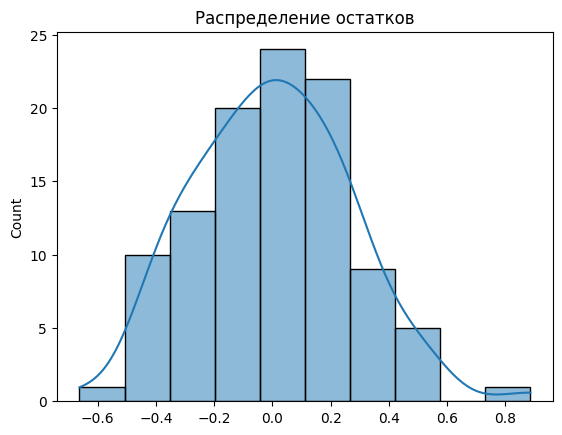

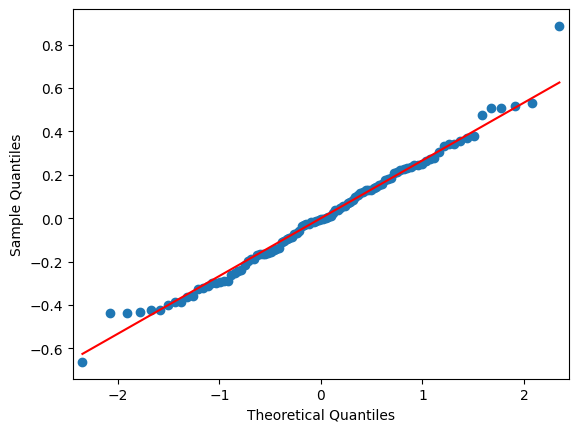

Breusch-Pagan test (LM stat, p-value): 35.205811531351436 0.01903513439771089


In [33]:
# базовая модель
model = sm.OLS(y, sm.add_constant(X)).fit()

# робастные ошибки HC3
robust = model.get_robustcov_results(cov_type='HC3')
print(robust.summary())

# диагностика остатков
resid = model.resid
sns.histplot(resid, kde=True)
plt.title("Распределение остатков")
plt.show()

sm.qqplot(resid, line='s')
plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(resid, model.model.exog)
print("Breusch-Pagan test (LM stat, p-value):", bp_test[0], bp_test[1])


### Устраняем мультиколлинеарность

In [34]:
df = processed_df_feed.copy()

# Уровни блоков: 'Кукуруза' заменена на 'Кукуруза_сухая' и 'Кукуруза_влажная'
df['Sum_conc']    = df[['Кукуруза_сухая', 'Кукуруза_влажная', 'Зерновые_прочие', 'Комбикорма', 'Корнаж_ЗСК']].sum(axis=1)
df['Sum_rough']   = df[['Сенаж', 'Сено', 'Солома']].sum(axis=1)

# Единый протеиновый уровень (без изменений)
df['Sum_prot_ex'] = df[['Шрот_соевый', 'Шрот_рапсовый', 'Шрот_подсолнечный']].sum(axis=1)
df['Sum_prot_pr'] = df[['Жмых_рапсовый', 'Жмых_льняной']].sum(axis=1)
df['Sum_prot']    = df['Sum_prot_ex'] + df['Sum_prot_pr']

eps = 1e-9

# Доли внутри всего протеина
df['share_prot_soy'] = np.where(df['Sum_prot'] > 0, df['Шрот_соевый'] / (df['Sum_prot'] + eps), 0.0)
df['share_prot_raps'] = np.where(df['Sum_prot'] > 0, df['Шрот_рапсовый'] / (df['Sum_prot'] + eps), 0.0)
df['share_prot_lin'] = np.where(df['Sum_prot'] > 0, df['Жмых_льняной'] / (df['Sum_prot'] + eps), 0.0)

# Доли в других блоках
df['share_kukur_wet']    = np.where(df['Sum_conc'] > 0, (df['Кукуруза_влажная']) / (df['Sum_conc'] + eps), 0.0)
df['share_kukur_dry']    = np.where(df['Sum_conc'] > 0, (df['Кукуруза_сухая']) / (df['Sum_conc'] + eps), 0.0)
df['share_korn']     = np.where(df['Sum_conc'] > 0, df['Корнаж_ЗСК'] / (df['Sum_conc'] + eps), 0.0)
df['share_zern']     = np.where(df['Sum_conc'] > 0, df['Зерновые_прочие'] / (df['Sum_conc'] + eps), 0.0)
df['share_soloma']   = np.where(df['Sum_rough'] > 0, df['Солома'] / (df['Sum_rough'] + eps), 0.0)

features = [
    # уровни
    'Sum_conc', 'Sum_prot', 'Sum_rough',
    # структура
    'share_kukur_wet', 'share_kukur_dry','share_korn', 'share_zern',
    'share_prot_soy', 'share_prot_raps', 'share_prot_lin',
    'share_soloma',
    # отдельные драйверы и побочки
    'Силос', 'Жиры', 'Жом_свекловичный', 'Патока_свекловичная', 'Побочные_прочие'
]

processed_df_model = pd.concat([df[['Источник']], df[features]], axis=1)

def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    Xc = sm.add_constant(X)
    return pd.DataFrame({
        'feature': ['const'] + list(X.columns),
        'VIF': [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
    })

vif_tbl = compute_vif(processed_df_model[features].astype(float))
print(vif_tbl)

                feature         VIF
0                 const  463.784925
1              Sum_conc    4.086618
2              Sum_prot    4.228091
3             Sum_rough    3.362351
4       share_kukur_wet    1.405402
5       share_kukur_dry    3.713177
6            share_korn    2.825143
7            share_zern    2.302967
8        share_prot_soy    5.305225
9       share_prot_raps    1.515053
10       share_prot_lin    2.658036
11         share_soloma    2.943478
12                Силос    2.822969
13                 Жиры    2.280865
14     Жом_свекловичный    2.610806
15  Патока_свекловичная    1.818765
16      Побочные_прочие    1.542738


Результат по анализу VIF приемлемый, можно считать что мультиколлинеарность устранена.

### Чистим модель

In [49]:
processed_df_model

Ингредиенты,Источник,Sum_conc,Sum_prot,Sum_rough,share_kukur_wet,share_kukur_dry,share_korn,share_zern,share_prot_soy,share_prot_raps,share_prot_lin,share_soloma,Силос,Жиры,Жом_свекловичный,Патока_свекловичная,Побочные_прочие
0,Д0 Высокое 25.02.25_ЭНАЛБ,4.160,3.400,3.200,0.0,0.480769,0.000000,0.000000,0.735294,0.000000,0.0,0.218750,5.74,0.000,0.800,0.700,0.0
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ,6.250,3.650,3.400,0.0,0.424000,0.000000,0.000000,0.684932,0.315068,0.0,0.441176,5.10,0.000,0.000,0.600,0.0
2,Д1 Бодеевка 25.02.25_ЭНАЛБ,7.300,5.150,3.250,0.0,0.589041,0.000000,0.000000,0.621359,0.000000,0.0,0.000000,6.70,0.000,1.300,1.300,0.0
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ,7.500,5.000,3.050,0.0,0.600000,0.000000,0.000000,0.640000,0.000000,0.0,0.081967,6.85,0.000,1.300,1.300,0.0
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,8.720,4.240,2.520,0.0,0.547018,0.000000,0.154817,0.650943,0.349057,0.0,0.000000,6.88,0.000,1.340,1.300,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ,8.686,5.200,3.000,0.0,0.000000,0.287819,0.189961,0.673077,0.326923,0.0,0.000000,8.32,0.369,0.525,0.900,0.0
88,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ,8.560,4.400,3.540,0.0,0.000000,0.350467,0.262850,0.681818,0.000000,0.0,0.000000,6.30,0.000,1.000,0.850,0.0
89,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ,9.201,4.600,3.300,0.0,0.000000,0.326052,0.217368,0.695652,0.304348,0.0,0.000000,6.00,0.350,0.750,0.800,0.0
90,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ,9.180,5.098,3.002,0.0,0.000000,0.329412,0.176471,0.699098,0.300902,0.0,0.000000,7.56,0.378,0.918,0.864,0.0


In [87]:
def fit_ols(acid_name, features, processed_df_model, coerce_features=True):

    X, y = form_dataset(acid_name, processed_df)

    # 2) OLS (HC3)
    Xc = sm.add_constant(X)
    ols = sm.OLS(y, Xc).fit(cov_type='HC3')

    print(ols.summary())

    # 3) Сохранение
    model_path = Path(f"D:/Python/econiva_app/ols_models/ols_{acid_name}.pkl")
    payload = {
        "model": ols,
        "features": list(features),
        "acid_name": acid_name,
        "add_constant": True
    }
    with open(model_path, "wb") as f:
        pkl.dump(payload, f)

    print(f"\nМодель сохранена в: {model_path.resolve()}")
    return ols, model_path


In [90]:
fit_ols('Лауриновая', features, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     8.909
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.74e-12
Time:                        15:54:16   Log-Likelihood:                -12.194
No. Observations:                 105   AIC:                             58.39
Df Residuals:                      88   BIC:                             103.5
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.7936    

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f1584d9150>,
 WindowsPath('D:/Python/econiva_app/ols_models/ols_Лауриновая.pkl'))

In [91]:
features_fin = [
    'Sum_conc',
    'share_korn',
    'share_zern',
    'share_prot_raps',
    'share_soloma',
    'Жиры',
    'Патока_свекловичная'
]
lauric_model = fit_ols('Лауриновая', features_fin, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                     18.89
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.08e-15
Time:                        15:54:17   Log-Likelihood:                -16.757
No. Observations:                 105   AIC:                             49.51
Df Residuals:                      97   BIC:                             70.74
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.5001    

In [62]:
fit_ols('Пальмитиновая', features, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     4.002
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.22e-05
Time:                        11:37:09   Log-Likelihood:                -179.41
No. Observations:                 105   AIC:                             392.8
Df Residuals:                      88   BIC:                             437.9
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  24.5784    

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f158646290>,
 WindowsPath('D:/Python/econiva_app/ols_models/ols_Пальмитиновая.pkl'))

In [63]:
features_fin = [
    'Sum_conc',
    'Sum_prot',
    'Sum_rough',
    'share_kukur_dry',
    'share_zern',
    'share_prot_soy',
    'share_prot_raps',
    'share_prot_lin',
    'share_soloma',
    'Жиры',
    'Патока_свекловичная',
    'Жом_свекловичный'
]
palmitic_model = fit_ols('Пальмитиновая', features_fin, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     5.625
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           3.77e-07
Time:                        11:37:19   Log-Likelihood:                -180.67
No. Observations:                 105   AIC:                             387.3
Df Residuals:                      92   BIC:                             421.8
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  27.4871    

In [64]:
fit_ols('Стеариновая', features, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     9.621
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           2.53e-13
Time:                        11:37:24   Log-Likelihood:                -106.20
No. Observations:                 105   AIC:                             246.4
Df Residuals:                      88   BIC:                             291.5
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  15.4148    

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f15853c3d0>,
 WindowsPath('D:/Python/econiva_app/ols_models/ols_Стеариновая.pkl'))

In [65]:
features_fin = [
    'Sum_conc',
    'Sum_rough',
    'share_kukur_wet',
    'share_kukur_dry',
    'share_korn',
    'share_zern',
    'share_prot_raps',
    'share_prot_lin',
    'share_soloma',
    'Жом_свекловичный',
    'Патока_свекловичная',
]
stearic_model = fit_ols('Стеариновая', features_fin, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     14.62
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           5.71e-16
Time:                        11:37:27   Log-Likelihood:                -107.88
No. Observations:                 105   AIC:                             239.8
Df Residuals:                      93   BIC:                             271.6
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  14.6749    

In [66]:
fit_ols('Олеиновая', features, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     9.913
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.17e-13
Time:                        11:37:30   Log-Likelihood:                -175.53
No. Observations:                 105   AIC:                             385.1
Df Residuals:                      88   BIC:                             430.2
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.4034    

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f1584b7a10>,
 WindowsPath('D:/Python/econiva_app/ols_models/ols_Олеиновая.pkl'))

In [68]:
features_fin = [
    'Sum_conc',
    'Sum_prot',
    'share_korn',
    'share_zern',
    'share_prot_soy',
    'share_prot_lin',
    'share_soloma',
    'Жом_свекловичный',
    'Патока_свекловичная',
]
oleic_model = fit_ols('Олеиновая', features_fin, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     18.52
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           2.02e-17
Time:                        11:37:32   Log-Likelihood:                -180.35
No. Observations:                 105   AIC:                             380.7
Df Residuals:                      95   BIC:                             407.2
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  26.4921    

In [69]:
fit_ols('Линолевая', features, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     4.605
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.37e-06
Time:                        11:37:35   Log-Likelihood:                 10.469
No. Observations:                 105   AIC:                             13.06
Df Residuals:                      88   BIC:                             58.18
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.6486    

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f1585ff410>,
 WindowsPath('D:/Python/econiva_app/ols_models/ols_Линолевая.pkl'))

In [71]:
features_fin = [
    'Sum_prot',
    'Sum_rough',
    'share_kukur_wet',
    'share_korn',
    'share_prot_lin',
    'share_soloma',
    'Силос',
    'Жом_свекловичный',
    'Патока_свекловичная'
]
oleic_model = fit_ols('Линолевая', features_fin, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     7.993
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.01e-08
Time:                        11:37:37   Log-Likelihood:                 6.8922
No. Observations:                 105   AIC:                             6.216
Df Residuals:                      95   BIC:                             32.76
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.2127    

In [72]:
fit_ols('Линоленовая', features, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     4.681
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.73e-06
Time:                        11:37:39   Log-Likelihood:                 174.16
No. Observations:                 103   AIC:                            -316.3
Df Residuals:                      87   BIC:                            -274.2
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4857    

D:\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 15
  warnings.warn('covariance of constraints does not have full '


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f1585821d0>,
 WindowsPath('D:/Python/econiva_app/ols_models/ols_Линоленовая.pkl'))

In [73]:
features_fin = [
    'Sum_prot',
    'share_soloma',
    'share_kukur_dry',
    'share_zern',
    'Силос',
    'Жом_свекловичный',
    'Побочные_прочие',
]
oleic_model = fit_ols('Линоленовая', features_fin, processed_df_model)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     9.459
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           7.35e-09
Time:                        11:37:41   Log-Likelihood:                 170.55
No. Observations:                 103   AIC:                            -325.1
Df Residuals:                      95   BIC:                            -304.0
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.5925      0.097  

# По нутриентам

In [94]:
processed_df_nutri

,Источник,aNDFom,CHO C uNDF,Крахмал,СП,Сол. КП,НВУ,Ca,Сахар (ВРУ),K,Mg,P,ОЖК,ЧЭЛ 3x NRC,Зола,Растворимая,СЖ
0,Д0 Высокое 25.02.25_ЭНАЛБ,5432.550,1561.370,4015.240,2993.990,1102.030,7183.700,165.0500,1186.930,295.4600,71.1700,68.2900,661.2000,127.7400,1532.130,0.000,804.2900
1,Д0 Отчет_Д0 ЖК Колыбелка 28.04.2025_ЭНАПБ,5829.184,1492.804,4251.973,3156.141,1188.854,7655.979,167.0084,1123.836,287.2838,72.4127,70.3400,620.1396,134.2544,1564.697,1645.445,741.1173
2,Д1 Бодеевка 25.02.25_ЭНАЛБ,6525.910,1693.900,6321.760,4204.240,1579.200,10973.310,216.0200,1957.310,396.9200,98.4100,101.0800,999.6500,183.4400,2029.840,0.000,1192.6100
3,Д1 ДОБРИНО 25.02.25_ЭНАЛБ,6726.530,1289.370,6505.530,4266.590,1520.010,10793.210,214.7300,1842.820,407.4100,95.5900,100.1000,982.1100,185.6700,1969.260,0.000,1170.3300
4,ЖК Бобров Д1 (КК-10) 25.02.2025(2)_ЭНАВ,6652.380,1578.590,6492.710,4198.030,1713.100,11371.440,203.9700,1999.190,399.6800,94.9500,94.0900,573.9800,179.0400,1947.900,1668.100,756.5100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Отчет_ЖК Богданино Д1 11.07.25_v2_КНЮ,7320.847,1587.632,7596.800,4593.969,1813.349,11892.540,228.3327,1628.827,384.5521,101.3595,107.4521,954.1677,194.4400,1966.162,1730.555,1151.8500
90,Отчет_ЖК Богданино Д1 14.04.25_v1_КНЮ,6560.809,1550.898,7041.644,4185.439,1525.988,11252.810,202.8279,1436.866,350.5228,86.0350,96.4466,954.2145,186.3527,1798.501,1823.910,1147.0950
91,Отчет_ЖК Богданино Д1 18.06.25_v1_КНЮ,6684.750,1506.214,7164.917,4247.114,1649.145,11057.740,215.8008,1443.529,364.8971,91.8227,101.2001,891.3765,180.3224,1871.727,1531.312,1071.0800
92,Отчет_ЖК Бушовка Д1 11.07.2025_v3_КНЮ,7159.492,1594.836,7592.144,4612.115,1758.365,12089.890,234.5823,1549.252,398.0822,102.9179,103.4868,987.5233,196.8845,1870.576,1921.503,1193.7550


### Углубленный анализ

In [95]:
X, y = form_dataset('Лауриновая', processed_df_nutri)
feed_cols = [c for c in processed_df_nutri.columns if c not in ('Источник', 'Ингредиенты')]
X

,aNDFom,CHO C uNDF,Крахмал,СП,Сол. КП,НВУ,Ca,Сахар (ВРУ),K,Mg,P,ОЖК,ЧЭЛ 3x NRC,Зола,Растворимая,СЖ
0,6371.470,1496.350,6499.470,4201.590,1674.210,11320.37,200.6800,1975.3200,412.6600,93.4200,92.6800,902.2800,185.8600,1952.410,1683.900,1080.4700
1,6529.370,1646.780,6667.690,4186.960,1619.950,11206.46,196.7300,1901.3100,392.6100,92.5900,95.6300,937.3800,185.1900,1889.630,1821.990,1113.9100
2,6652.380,1578.590,6492.710,4198.030,1713.100,11371.44,203.9700,1999.1900,399.6800,94.9500,94.0900,573.9800,179.0400,1947.900,1668.100,756.5100
3,6666.600,1610.180,6431.920,4175.470,1680.480,11069.30,203.3300,2024.0100,424.5100,93.3200,96.8300,896.2400,183.6200,1944.880,1626.000,1070.0500
4,7080.130,1799.220,6389.980,4169.780,1665.170,11015.99,201.3600,2021.3200,410.5700,93.7300,97.6800,561.2100,176.1800,1928.800,1652.960,731.5600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,6798.259,1586.159,7059.823,4167.199,1495.314,11040.57,205.1363,1447.0110,349.1659,84.1703,95.1910,963.9990,187.4255,1785.096,1631.988,1153.5250
102,7235.077,2262.238,5655.516,3570.475,1043.030,8499.16,201.2345,798.8052,254.9827,88.2631,99.4884,603.9374,146.9010,1791.599,0.000,856.9101
103,6749.123,1928.630,6499.746,4120.025,1507.430,10891.30,210.3706,1832.5800,403.2130,93.4816,104.8995,868.9172,184.3130,2028.449,0.000,1145.9860
104,10655.461,1609.075,7137.229,4272.300,0.000,11197.17,208.8756,1772.6790,390.9233,94.8811,99.8619,937.1553,186.3902,1899.501,1459.499,1149.7900


In [96]:
# VIF для исходных нутриентов
X_vif = sm.add_constant(X[feed_cols])
vif_data = pd.DataFrame({
    "feature": ["const"] + feed_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)

# Ridge с кросс-валидацией
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X, y)
print("Ridge alpha:", ridge.alpha_, "R²:", ridge.score(X, y))

# ElasticNet с кросс-валидацией
en = ElasticNetCV(l1_ratio=[.1,.5,.9], alphas=np.logspace(-3,3,30), cv=5)
en.fit(X, y)
print("ElasticNet alpha:", en.alpha_, "l1_ratio:", en.l1_ratio_, "R²:", en.score(X, y))


        feature         VIF
0         const  488.306334
1        aNDFom    5.367441
2    CHO C uNDF    4.664423
3       Крахмал   64.540370
4            СП   26.902282
5       Сол. КП    3.626595
6           НВУ   72.269378
7            Ca    4.849743
8   Сахар (ВРУ)   15.027009
9             K    8.162413
10           Mg    5.504530
11            P    5.446203
12          ОЖК    4.652335
13   ЧЭЛ 3x NRC    5.332205
14         Зола   10.133744
15  Растворимая    2.539521
16           СЖ    3.566022
Ridge alpha: 323.745754281764 R²: 0.6965429961709351
ElasticNet alpha: 2.0433597178569416 l1_ratio: 0.5 R²: 0.6189686521504405


In [97]:
# k-fold CV для проверки стабильности знаков
kf = KFold(n_splits=5, shuffle=True, random_state=42)
signs = {c: [] for c in feed_cols}

for train_idx, test_idx in kf.split(X):
    model = sm.OLS(y[train_idx], sm.add_constant(X.loc[train_idx])).fit()
    for i, c in enumerate(feed_cols):
        signs[c].append(np.sign(model.params[i+1]))

sign_stability = {c: np.mean(np.array(v) > 0) for c, v in signs.items()}
print("Доля положительных знаков по CV:", sign_stability)

# bootstrap коэффициентов
boot_coefs = []
for b in range(500):
    Xb, yb = resample(X, y)
    model = sm.OLS(yb, sm.add_constant(Xb)).fit()
    boot_coefs.append(model.params[1:])  # без intercept
boot_coefs = np.array(boot_coefs)

coef_means = boot_coefs.mean(axis=0)
ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)

coef_table = pd.DataFrame({
    "coef_mean": coef_means,
    "ci_low": ci_low,
    "ci_high": ci_high
}, index=feed_cols)
print(coef_table)


C:\Users\Петр\AppData\Local\Temp\ipykernel_482484\169527319.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signs[c].append(np.sign(model.params[i+1]))
C:\Users\Петр\AppData\Local\Temp\ipykernel_482484\169527319.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signs[c].append(np.sign(model.params[i+1]))
C:\Users\Петр\AppData\Local\Temp\ipykernel_482484\169527319.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  signs[c].app

Доля положительных знаков по CV: {'aNDFom': 0.8, 'CHO C uNDF': 0.0, 'Крахмал': 1.0, 'СП': 0.6, 'Сол. КП': 1.0, 'НВУ': 0.0, 'Ca': 0.0, 'Сахар (ВРУ)': 0.0, 'K': 1.0, 'Mg': 1.0, 'P': 0.0, 'ОЖК': 0.0, 'ЧЭЛ 3x NRC': 0.8, 'Зола': 1.0, 'Растворимая': 0.4, 'СЖ': 0.0}
             coef_mean    ci_low   ci_high
aNDFom        0.000033 -0.000050  0.000115
CHO C uNDF   -0.000280 -0.000647  0.000096
Крахмал       0.000478 -0.000046  0.000951
СП            0.000147 -0.000667  0.000950
Сол. КП       0.000189 -0.000013  0.000439
НВУ          -0.000087 -0.000461  0.000336
Ca           -0.007671 -0.013112 -0.002054
Сахар (ВРУ)  -0.000281 -0.001109  0.000531
K             0.004152 -0.000432  0.008026
Mg            0.012906  0.000786  0.028308
P            -0.017862 -0.033739  0.001074
ОЖК          -0.000929 -0.001522 -0.000312
ЧЭЛ 3x NRC    0.000949 -0.000820  0.002595
Зола          0.000657 -0.000038  0.001279
Растворимая  -0.000010 -0.000136  0.000117
СЖ           -0.000187 -0.000617  0.000145


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     9.932
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           9.63e-14
Time:                        18:51:09   Log-Likelihood:                -10.337
No. Observations:                 106   AIC:                             54.67
Df Residuals:                      89   BIC:                             99.95
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.7708      0.623      2.842      

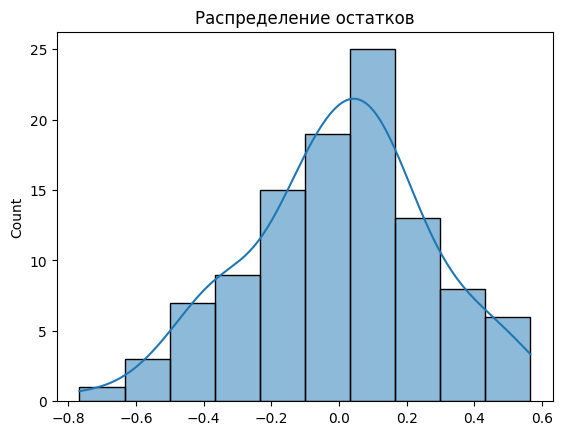

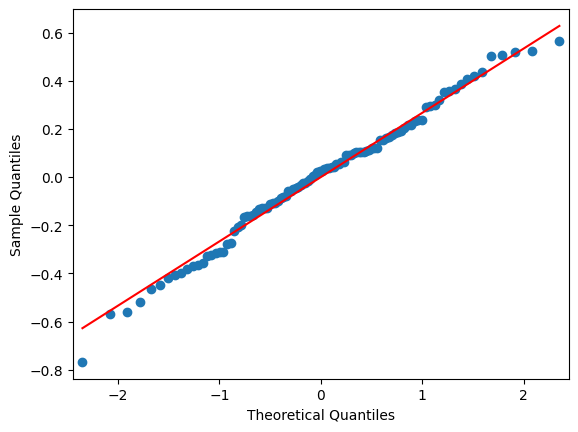

Breusch-Pagan test (LM stat, p-value): 14.703775362570804 0.5464320148230266


In [98]:
# базовая модель
model = sm.OLS(y, sm.add_constant(X)).fit()

# робастные ошибки HC3
robust = model.get_robustcov_results(cov_type='HC3')
print(robust.summary())

# диагностика остатков
resid = model.resid
sns.histplot(resid, kde=True)
plt.title("Распределение остатков")
plt.show()

sm.qqplot(resid, line='s')
plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(resid, model.model.exog)
print("Breusch-Pagan test (LM stat, p-value):", bp_test[0], bp_test[1])


### Чистим модель

In [93]:
# # Пытаемся устранить мультиколлинеарность для нутриентов. Не вышло, поэтому в финальных моделях оставляем как есть.
# def compute_vif(X: pd.DataFrame, description: str):
#     """Рассчитывает и выводит VIF для переданного набора признаков."""
#     print(f"\n--- {description} ---")
#     if X.empty:
#         print("DataFrame пуст.")
#         return
        
#     X_cleaned = X.dropna()
#     if X_cleaned.shape[0] < X.shape[0]:
#         print(f"Предупреждение: {X.shape[0] - X_cleaned.shape[0]} строк с NaN было удалено перед расчетом VIF.")

#     if X_cleaned.shape[0] < 2:
#         print("Недостаточно данных для расчета VIF после удаления NaN.")
#         return

#     Xc = sm.add_constant(X_cleaned.astype(float))
#     vif_data = pd.DataFrame({
#         'feature': ['const'] + list(X_cleaned.columns),
#         'VIF': [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
#     })
#     print(vif_data.round(2))


# # --- 3. Анализ исходных данных ---
# initial_features = [
#     'aNDFom', 'CHO C uNDF', 'Крахмал', 'СП', 'Сол. КП', 'НВУ', 'Ca',
#     'Сахар (ВРУ)', 'K', 'Mg', 'P', 'ОЖК', 'ЧЭЛ 3x NRC', 'Зола',
#     'Растворимая', 'СЖ'
# ]
# compute_vif(processed_df_nutri[initial_features], "VIF для ИСХОДНЫХ признаков")


# # --- 4. Этап 1: Преобразование внутри групп ---
# df = processed_df_nutri.copy()
# eps = 1e-9

# # Углеводы
# df['share_Крахмал_in_НВУ'] = np.where(df['НВУ'] > 0, df['Крахмал'] / (df['НВУ'] + eps), 0.0)
# df['share_Сахар_in_НВУ'] = np.where(df['НВУ'] > 0, df['Сахар (ВРУ)'] / (df['НВУ'] + eps), 0.0)
# # Минералы
# df['share_Ca_in_Зола'] = np.where(df['Зола'] > 0, df['Ca'] / (df['Зола'] + eps), 0.0)
# df['share_K_in_Зола']  = np.where(df['Зола'] > 0, df['K'] / (df['Зола'] + eps), 0.0)
# df['share_P_in_Зола']  = np.where(df['Зола'] > 0, df['P'] / (df['Зола'] + eps), 0.0)
# df['share_Mg_in_Зола'] = np.where(df['Зола'] > 0, df['Mg'] / (df['Зола'] + eps), 0.0)
# # Протеин
# df['share_Растворимая_in_СП'] = np.where(df['СП'] > 0, df['Растворимая'] / (df['СП'] + eps), 0.0)


# # --- 5. Этап 2: Финальное преобразование с ИСПРАВЛЕННОЙ логикой ---
# # Создаем суперагрегат "Органическое вещество"
# organic_matter_cols = ['СП', 'НВУ', 'СЖ', 'aNDFom']
# df['Органическое_вещество'] = df[organic_matter_cols].sum(axis=1)

# # Выражаем ВСЕ ключевые компоненты как долю от нового общего уровня
# df['share_СП_in_ОВ'] = np.where(df['Органическое_вещество'] > 0, df['СП'] / (df['Органическое_вещество'] + eps), 0.0)
# df['share_НВУ_in_ОВ'] = np.where(df['Органическое_вещество'] > 0, df['НВУ'] / (df['Органическое_вещество'] + eps), 0.0)
# df['share_СЖ_in_ОВ'] = np.where(df['Органическое_вещество'] > 0, df['СЖ'] / (df['Органическое_вещество'] + eps), 0.0)
# df['share_aNDFom_in_ОВ'] = np.where(df['Органическое_вещество'] > 0, df['aNDFom'] / (df['Органическое_вещество'] + eps), 0.0)


# # Формируем финальный список признаков
# # Принцип: включаем агрегаты и n-k долей, ИСКЛЮЧАЕМ исходные компоненты.
# features_final = [
#     # ГЛАВНЫЕ УРОВНИ
#     'Органическое_вещество',
#     'Зола',
    
#     # СТРУКТУРА ОРГАНИЧЕСКОГО ВЕЩЕСТВА (n-2 = 2 из 4 долей)
#     # Удаляем доли с наибольшей коллинеарностью ('share_aNDFom_in_ОВ' и 'share_СЖ_in_ОВ'),
#     # чтобы VIF всех признаков был < 10.
#     'share_СП_in_ОВ',
#     'share_НВУ_in_ОВ',
    
#     # СТРУКТУРА УГЛЕВОДОВ (внутри НВУ)
#     'share_Крахмал_in_НВУ',
#     'share_Сахар_in_НВУ',

#     # СТРУКТУРА МИНЕРАЛОВ (внутри Золы, n-1 = 3 из 4 долей)
#     # Удаляем 'share_P_in_Зола'
#     'share_Ca_in_Зола',
#     'share_K_in_Зола',
#     'share_Mg_in_Зола',
    
#     # СТРУКТУРА ПРОТЕИНА (внутри СП)
#     'share_Растворимая_in_СП',
    
#     # ОСТАЛЬНЫЕ НЕЗАВИСИМЫЕ ПРИЗНАКИ (не входили в агрегаты)
#     'CHO C uNDF',
#     'Сол. КП',
#     'ОЖК',
#     'ЧЭЛ 3x NRC',
# ]

# # Создаем финальный датафрейм для модели, включая 'Источник'
# processed_df_nutri_final = pd.concat([df[['Источник']], df[features_final]], axis=1)

# compute_vif(processed_df_nutri_final[features_final], "VIF после ФИНАЛЬНОГО преобразования (проблема решена)")

# print("\nФинальный датафрейм готов в переменной 'processed_df_nutri_final'")
# print(processed_df_nutri_final.head())

In [102]:
def fit_ols(acid_name, features, processed_df_model, coerce_features=True):

    X, y = form_dataset(acid_name, processed_df_model)

    # 2) OLS (HC3)
    Xc = sm.add_constant(X)
    ols = sm.OLS(y, Xc).fit(cov_type='HC3')

    print(ols.summary())

    # 3) Сохранение
    model_path = Path(f"D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_{acid_name}.pkl")
    payload = {
        "model": ols,
        "features": list(features),
        "acid_name": acid_name,
        "add_constant": True
    }
    with open(model_path, "wb") as f:
        pkl.dump(payload, f)

    print(f"\nМодель сохранена в: {model_path.resolve()}")
    return ols, model_path


In [103]:
fit_ols('Лауриновая', processed_df_nutri.columns[1:].tolist(), processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     9.932
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           9.63e-14
Time:                        18:55:13   Log-Likelihood:                -10.337
No. Observations:                 106   AIC:                             54.67
Df Residuals:                      89   BIC:                             99.95
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.7708      0.623      2.842      

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f1585aba10>,
 WindowsPath('D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_Лауриновая.pkl'))

In [104]:
fit_ols('Пальмитиновая', processed_df_nutri.columns[1:].tolist(), processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     5.450
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           6.75e-08
Time:                        18:55:35   Log-Likelihood:                -183.56
No. Observations:                 106   AIC:                             401.1
Df Residuals:                      89   BIC:                             446.4
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          22.4073      3.580      6.259      

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f15881a710>,
 WindowsPath('D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_Пальмитиновая.pkl'))

In [105]:
fit_ols('Олеиновая', processed_df_nutri.columns[1:].tolist(), processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     9.105
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           8.91e-13
Time:                        18:55:37   Log-Likelihood:                -185.74
No. Observations:                 106   AIC:                             405.5
Df Residuals:                      89   BIC:                             450.8
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.9819      3.076     11.697      

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f15864da10>,
 WindowsPath('D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_Олеиновая.pkl'))

In [106]:
fit_ols('Стеариновая', processed_df_nutri.columns[1:].tolist(), processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     8.273
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           9.30e-12
Time:                        18:55:37   Log-Likelihood:                -116.18
No. Observations:                 106   AIC:                             266.4
Df Residuals:                      89   BIC:                             311.6
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          15.2963      1.877      8.151      

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f158582290>,
 WindowsPath('D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_Стеариновая.pkl'))

In [107]:
fit_ols('Линолевая', processed_df_nutri.columns[1:].tolist(), processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     4.766
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           7.35e-07
Time:                        18:55:39   Log-Likelihood:                 3.1899
No. Observations:                 106   AIC:                             27.62
Df Residuals:                      89   BIC:                             72.90
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6385      0.605      4.362      

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f1584d8c90>,
 WindowsPath('D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_Линолевая.pkl'))

In [108]:
fit_ols('Линоленовая', processed_df_nutri.columns[1:].tolist(), processed_df_nutri)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     4.766
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           8.12e-07
Time:                        18:55:40   Log-Likelihood:                 178.78
No. Observations:                 104   AIC:                            -323.6
Df Residuals:                      87   BIC:                            -278.6
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3436      0.243      1.413      

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1f15865d250>,
 WindowsPath('D:/Python/econiva_app/ols_models_nutrients/ols_nutrients_Линоленовая.pkl'))